In [ ]:

import numpy as np 
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import pickle
import time
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, LSTM, GRU, Embedding, Dropout, Add, concatenate
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle


tf.random.set_seed(42)
np.random.seed(42)

plt.style.use('ggplot')

2025-08-25 18:56:03.678429: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756148163.936606      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756148164.009911      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:

base_dir = '/kaggle/input/flickr8k'
images_dir = os.path.join(base_dir, 'Images')
captions_file = os.path.join(base_dir, 'captions.txt')


captions_df = pd.read_csv(captions_file)
print(f"Dataset size: {len(captions_df)}")
print(f"Number of unique images: {captions_df['image'].nunique()}")

captions_df.head()

Dataset size: 40455
Number of unique images: 8091


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [ ]:
def preprocess_caption(caption):
    """Preprocess captions: lowercase, remove punctuation, add start/end tokens"""
    caption = caption.lower()
    caption = caption.replace('[^A-Za-z]', ' ')
    caption = caption.replace('\s+', ' ')
    caption = caption.strip()
    caption = 'startseq ' + caption + ' endseq'
    return caption

captions_df['caption'] = captions_df['caption'].apply(preprocess_caption)


print("Sample captions after preprocessing:")
for i in range(5):
    print(captions_df['caption'].iloc[i])

Sample captions after preprocessing:
startseq a child in a pink dress is climbing up a set of stairs in an entry way . endseq
startseq a girl going into a wooden building . endseq
startseq a little girl climbing into a wooden playhouse . endseq
startseq a little girl climbing the stairs to her playhouse . endseq
startseq a little girl in a pink dress going into a wooden cabin . endseq


In [ ]:

tokenizer = Tokenizer(
    num_words=5000,  
    oov_token="<unk>",
    filters='!"#$%&()*+.,-/:;=?@[\\]^_`{|}~ '
)
tokenizer.fit_on_texts(captions_df['caption'])


vocab_size = len(tokenizer.word_index) + 1
print(f"Vocabulary size: {vocab_size}")


max_length = max(len(caption.split()) for caption in captions_df['caption'])
print(f"Maximum caption length: {max_length}")


with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

Vocabulary size: 8497
Maximum caption length: 40


In [ ]:

try:
    
    vgg_model = VGG16(weights='imagenet')
    print("VGG16 model loaded with ImageNet weights")
except:
   
    try:
        
        vgg16_weights_path = '/kaggle/input/vgg16-weights/vgg16_weights_tf_dim_ordering_tf_kernels.h5'
        vgg_model = VGG16(weights=vgg16_weights_path)
        print("VGG16 model loaded from Kaggle dataset")
    except:
        
        print("Warning: Using VGG16 with random weights (not recommended for production)")
        vgg_model = VGG16(weights=None)
        

vgg_model = Model(inputs=vgg_model.input, outputs=vgg_model.layers[-2].output)


def extract_features(image_path):
    try:
        
        img = load_img(image_path, target_size=(224, 224))
        
        img = img_to_array(img)
        img = img.reshape((1, img.shape[0], img.shape[1], img.shape[2]))
        img = tf.keras.applications.vgg16.preprocess_input(img)
        
        features = vgg_model.predict(img, verbose=0)
        return features
    except Exception as e:
        print(f"Error processing image {image_path}: {e}")
        return None


features_cache = {}


image_files = captions_df['image'].unique()[:50] 

print("Extracting image features...")
success_count = 0
for i, image_file in enumerate(image_files):
    try:
        image_path = os.path.join(images_dir, image_file)
        features = extract_features(image_path)
        if features is not None:
            features_cache[image_file] = features
            success_count += 1
        
        if (i+1) % 10 == 0:
            print(f"Processed {i+1}/{len(image_files)} images")
    except Exception as e:
        print(f"Error with image {image_file}: {e}")

print(f"Successfully processed {success_count}/{len(image_files)} images")


with open('image_features.pkl', 'wb') as f:
    pickle.dump(features_cache, f)

print("Feature extraction completed!")

2025-08-25 18:58:22.088222: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
VGG16 model loaded with ImageNet weights
Extracting image features...
Processed 10/50 images
Processed 20/50 images
Processed 30/50 images
Processed 40/50 images
Processed 50/50 images
Successfully processed 50/50 images
Feature extraction completed!


In [ ]:

image_to_captions = {}
for _, row in captions_df.iterrows():
    image_name = row['image']
    caption = row['caption']
    
    if image_name not in image_to_captions:
        image_to_captions[image_name] = []
    image_to_captions[image_name].append(caption)


def create_sequences(tokenizer, max_length, captions_list, feature):
    X1, X2, y = [], [], []
    
    
    for caption in captions_list:
        seq = tokenizer.texts_to_sequences([caption])[0]
        
        
        for i in range(1, len(seq)):
            in_seq, out_seq = seq[:i], seq[i]
            in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
            out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
            
            X1.append(feature)
            X2.append(in_seq)
            y.append(out_seq)
    
    return np.array(X1), np.array(X2), np.array(y)


print("Preparing training data...")
X1, X2, y = [], [], []

for image_name, captions in image_to_captions.items():
    if image_name in features_cache:
        feature = features_cache[image_name][0] 
        img_X1, img_X2, img_y = create_sequences(tokenizer, max_length, captions, feature)
        
        X1.extend(img_X1)
        X2.extend(img_X2)
        y.extend(img_y)

X1, X2, y = np.array(X1), np.array(X2), np.array(y)
print(f"Training data shape: X1={X1.shape}, X2={X2.shape}, y={y.shape}")

Preparing training data...
Training data shape: X1=(3053, 4096), X2=(3053, 40), y=(3053, 8497)


Preparing tokenizer and vocabulary...
Vocabulary size: 8496
Maximum caption length: 42
Total captions: 40455

Preparing training data...
Training data shape: X1=(3553, 4096), X2=(3553, 42), y=(3553, 8496)

Splitting data...
Training set: X1=(2842, 4096), X2=(2842, 42), y=(2842, 8496)
Validation set: X1=(711, 4096), X2=(711, 42), y=(711, 8496)

CREATING GRU IMAGE CAPTIONING MODEL

Creating GRU model with:
  - Vocabulary size: 8496
  - Max sequence length: 42
  - Feature dimension: 4096

Compiling model...

Model Architecture:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 42)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_features      │ (None, 4096)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 42, 256)   │  2,174,976 │ sequence_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 4096)      │          0 │ image_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 42, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 42)        │          0 │ sequence_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_dense (Dense) │ (None, 256)       │  1,048,832 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 256)       │    394,752 │ dropout_1[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_features (Add)  │ (None, 256)       │          0 │ image_dense[0][0… │
│                     │                   │            │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense1      │ (None, 256)       │     65,792 │ add_features[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ decoder_dense1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 8496)      │  2,183,472 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,867,824 (22.38 MB)

 Trainable params: 5,867,824 (22.38 MB)

 Non-trainable params: 0 (0.00 B)


Model architecture saved as 'gru_captioning_model.png'

STARTING MODEL TRAINING
Training parameters:
  - Batch size: 32
  - Epochs: 20
  - Training samples: 2842
  - Validation samples: 711
Epoch 1/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.1010 - loss: 6.6607
Epoch 1: val_loss improved from inf to 4.88936, saving model to best_gru_captioning_model.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 18s 136ms/step - accuracy: 0.1014 - loss: 6.6520 - val_accuracy: 0.2222 - val_loss: 4.8894
Epoch 2/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.2326 - loss: 4.4955
Epoch 2: val_loss improved from 4.88936 to 4.30301, saving model to best_gru_captioning_model.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 127ms/step - accuracy: 0.2326 - loss: 4.4954 - val_accuracy: 0.2771 - val_loss: 4.3030
Epoch 3/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.2994 - loss: 3.8714
Epoch 3: val_loss improved from 4.30301 to 4.12610, saving model to best_gru_captioning_model.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 1

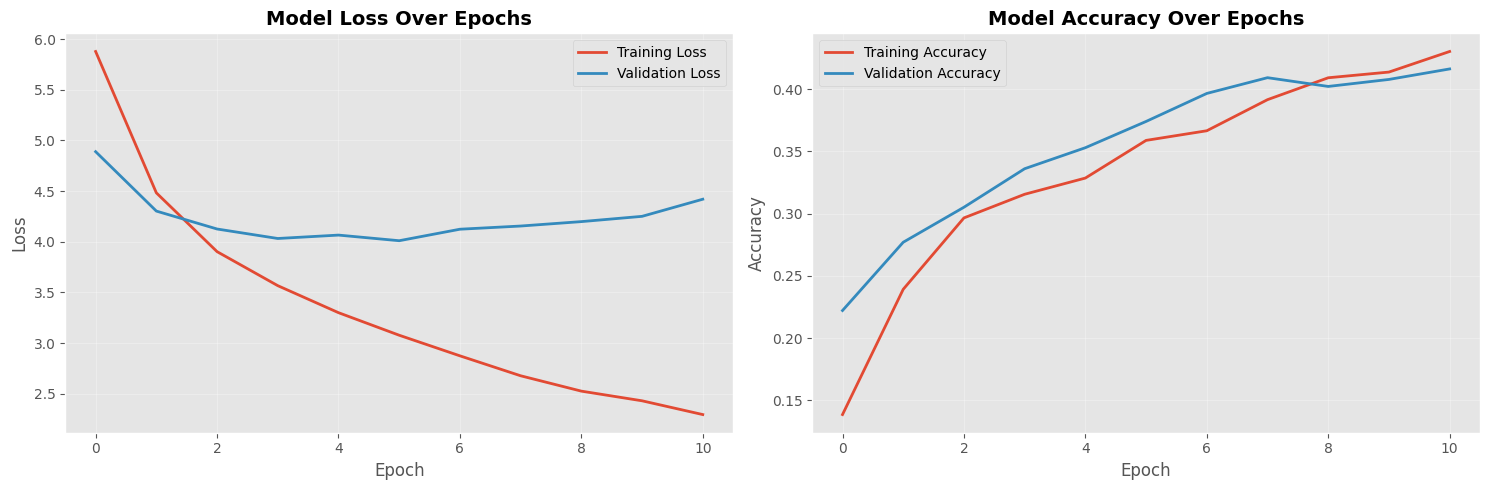


Final Training Results:
  - Training Loss: 2.2946
  - Validation Loss: 4.4201
  - Training Accuracy: 0.4303
  - Validation Accuracy: 0.4163

SAMPLE PREDICTIONS

Sample 1:
Predicted: a brown dog brown a brown brown brown brown brown brown brown brown brown brown brown brown brown brown brown brown brown brown brown brown brown brown brown brown brown brown brown brown brown brown brown brown brown brown brown brown

Sample 2:
Predicted: a man man a ice ice ice ice

Sample 3:
Predicted: a girl girl in a girl in a in in a in in a in in a in in a in in a in in a in in a in in a in in in a in in in a in

Sample 4:
Predicted: a girl girl in a girl in a in in a in in a in in a in in a in in a in in a in in a in in a in in in a in in in a in

Sample 5:
Predicted: a dog dog dog catch a catch a catch

MODEL TRAINING COMPLETED SUCCESSFULLY!
Files saved:
  - best_gru_captioning_model.h5 (best model)
  - final_gru_captioning_model.h5 (final model)
  - tokenizer.pkl (tokenizer)
  - image_features.p

In [ ]:

print("Preparing tokenizer and vocabulary...")


all_captions = []
for captions_list in image_to_captions.values():
    for caption in captions_list:
        
        caption = 'startseq ' + caption + ' endseq'
        all_captions.append(caption)


tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)


vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(caption.split()) for caption in all_captions)

print(f"Vocabulary size: {vocab_size}")
print(f"Maximum caption length: {max_length}")
print(f"Total captions: {len(all_captions)}")


def create_sequences(tokenizer, max_length, captions_list, feature):
    X1, X2, y = [], [], []
    
    
    for caption in captions_list:
        
        caption = 'startseq ' + caption + ' endseq'
        seq = tokenizer.texts_to_sequences([caption])[0]
        
        
        for i in range(1, len(seq)):
            in_seq, out_seq = seq[:i], seq[i]
            in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
            out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
            
            X1.append(feature)
            X2.append(in_seq)
            y.append(out_seq)
    
    return np.array(X1), np.array(X2), np.array(y)


print("\nPreparing training data...")
X1, X2, y = [], [], []
for image_name, captions in image_to_captions.items():
    if image_name in features_cache:
        feature = features_cache[image_name][0]  
        img_X1, img_X2, img_y = create_sequences(tokenizer, max_length, captions, feature)
        
        X1.extend(img_X1)
        X2.extend(img_X2)
        y.extend(img_y)

X1, X2, y = np.array(X1), np.array(X2), np.array(y)
print(f"Training data shape: X1={X1.shape}, X2={X2.shape}, y={y.shape}")


print("\nSplitting data...")
X1_train, X1_val, X2_train, X2_val, y_train, y_val = train_test_split(
    X1, X2, y, test_size=0.2, random_state=42
)

print(f"Training set: X1={X1_train.shape}, X2={X2_train.shape}, y={y_train.shape}")
print(f"Validation set: X1={X1_val.shape}, X2={X2_val.shape}, y={y_val.shape}")


def create_gru_model(vocab_size, max_length, feature_dim=4096):
    """
    Create a GRU-based image captioning model
    """
    print(f"\nCreating GRU model with:")
    print(f"  - Vocabulary size: {vocab_size}")
    print(f"  - Max sequence length: {max_length}")
    print(f"  - Feature dimension: {feature_dim}")
    
    
    input1 = Input(shape=(feature_dim,), name='image_features')
    fe1 = Dropout(0.5)(input1)
    fe2 = Dense(256, activation='relu', name='image_dense')(fe1)
    
    
    input2 = Input(shape=(max_length,), name='sequence_input')
    se1 = Embedding(vocab_size, 256, mask_zero=True, name='embedding')(input2)
    se2 = Dropout(0.5)(se1)
    se3 = GRU(256, return_sequences=False, name='gru')(se2)
    
    
    decoder1 = Add(name='add_features')([fe2, se3])
    decoder2 = Dense(256, activation='relu', name='decoder_dense1')(decoder1)
    decoder3 = Dropout(0.5)(decoder2)
    
    
    outputs = Dense(vocab_size, activation='softmax', name='output')(decoder3)
    
    
    model = Model(inputs=[input1, input2], outputs=outputs)
    
    return model


print("\n" + "="*50)
print("CREATING GRU IMAGE CAPTIONING MODEL")
print("="*50)

model = create_gru_model(vocab_size, max_length, feature_dim=X1.shape[1])


print("\nCompiling model...")
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


print("\nModel Architecture:")
model.summary()


try:
    plot_model(model, to_file='gru_captioning_model.png', show_shapes=True, show_layer_names=True)
    print("\nModel architecture saved as 'gru_captioning_model.png'")
except:
    print("\nNote: Could not save model plot (graphviz may not be installed)")


callbacks = [
    ModelCheckpoint(
        'best_gru_captioning_model.h5',
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        verbose=1,
        restore_best_weights=True
    )
]


print("\n" + "="*50)
print("STARTING MODEL TRAINING")
print("="*50)

start_time = time.time()

batch_size = 32
epochs = 20

print(f"Training parameters:")
print(f"  - Batch size: {batch_size}")
print(f"  - Epochs: {epochs}")
print(f"  - Training samples: {len(X1_train)}")
print(f"  - Validation samples: {len(X1_val)}")

try:
    history = model.fit(
        [X1_train, X2_train], y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=([X1_val, X2_val], y_val),
        callbacks=callbacks,
        verbose=1
    )
    
    training_time = time.time() - start_time
    print(f"\nTraining completed in {training_time/60:.2f} minutes!")
    
except Exception as e:
    print(f"Training error: {e}")
    print("Trying with smaller batch size...")
    
    
    batch_size = 16
    history = model.fit(
        [X1_train, X2_train], y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=([X1_val, X2_val], y_val),
        callbacks=callbacks,
        verbose=1
    )
    
    training_time = time.time() - start_time
    print(f"\nTraining completed in {training_time/60:.2f} minutes!")


model.save('final_gru_captioning_model.h5')
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("\nModel and tokenizer saved successfully!")


def plot_training_history(history):
    """Plot training and validation metrics"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    
    ax1.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax1.set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    
    ax2.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax2.set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


print("\n" + "="*50)
print("TRAINING RESULTS")
print("="*50)

plot_training_history(history)


final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"\nFinal Training Results:")
print(f"  - Training Loss: {final_train_loss:.4f}")
print(f"  - Validation Loss: {final_val_loss:.4f}")
print(f"  - Training Accuracy: {final_train_acc:.4f}")
print(f"  - Validation Accuracy: {final_val_acc:.4f}")


def generate_caption(model, tokenizer, feature, max_length):
    """Generate caption for a given image feature"""
    in_text = 'startseq'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        pred = model.predict([feature, sequence], verbose=0)
        pred = np.argmax(pred)
        word = tokenizer.index_word.get(pred)
        if word is None:
            break
        in_text += ' ' + word
        if word == 'endseq':
            break
    return in_text.replace('startseq ', '').replace(' endseq', '')


print("\n" + "="*50)
print("SAMPLE PREDICTIONS")
print("="*50)


sample_indices = np.random.choice(len(X1_val), min(5, len(X1_val)), replace=False)

for i, idx in enumerate(sample_indices):
    feature = X1_val[idx:idx+1]  
    predicted_caption = generate_caption(model, tokenizer, feature, max_length)
    print(f"\nSample {i+1}:")
    print(f"Predicted: {predicted_caption}")

print("\n" + "="*50)
print("MODEL TRAINING COMPLETED SUCCESSFULLY!")
print("="*50)
print(f"Files saved:")
print(f"  - best_gru_captioning_model.h5 (best model)")
print(f"  - final_gru_captioning_model.h5 (final model)")
print(f"  - tokenizer.pkl (tokenizer)")
print(f"  - image_features.pkl (image features)")

Preparing tokenizer and vocabulary...
Vocabulary size: 8496
Maximum caption length: 42
Total captions: 40455

Preparing training data...
Training data shape: X1=(3553, 4096), X2=(3553, 42), y=(3553, 8496)

Splitting data...
Training set: X1=(2842, 4096), X2=(2842, 42), y=(2842, 8496)
Validation set: X1=(711, 4096), X2=(711, 42), y=(711, 8496)

CREATING GRU IMAGE CAPTIONING MODEL

Creating GRU model with:
  - Vocabulary size: 8496
  - Max sequence length: 42
  - Feature dimension: 4096

Compiling model...

Model Architecture:


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 42)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_features      │ (None, 4096)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 42, 256)   │  2,174,976 │ sequence_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 4096)      │          0 │ image_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 42, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 42)        │          0 │ sequence_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_dense (Dense) │ (None, 256)       │  1,048,832 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 256)       │    394,752 │ dropout_4[0][0],  │
│                     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_features (Add)  │ (None, 256)       │          0 │ image_dense[0][0… │
│                     │                   │            │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense1      │ (None, 256)       │     65,792 │ add_features[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 256)       │          0 │ decoder_dense1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 8496)      │  2,183,472 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,867,824 (22.38 MB)

 Trainable params: 5,867,824 (22.38 MB)

 Non-trainable params: 0 (0.00 B)


Model architecture saved as 'gru_captioning_model.png'

STARTING MODEL TRAINING
Training parameters:
  - Batch size: 32
  - Epochs: 20
  - Training samples: 2842
  - Validation samples: 711
Epoch 1/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.1123 - loss: 6.5420
Epoch 1: val_loss improved from inf to 4.90573, saving model to best_gru_captioning_model.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 17s 133ms/step - accuracy: 0.1128 - loss: 6.5337 - val_accuracy: 0.2307 - val_loss: 4.9057
Epoch 2/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.2438 - loss: 4.4879
Epoch 2: val_loss improved from 4.90573 to 4.37761, saving model to best_gru_captioning_model.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - accuracy: 0.2439 - loss: 4.4879 - val_accuracy: 0.2827 - val_loss: 4.3776
Epoch 3/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.2904 - loss: 3.9084
Epoch 3: val_loss improved from 4.37761 to 4.17169, saving model to best_gru_captioning_model.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 1

/tmp/ipykernel_36/1419402944.py:344: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


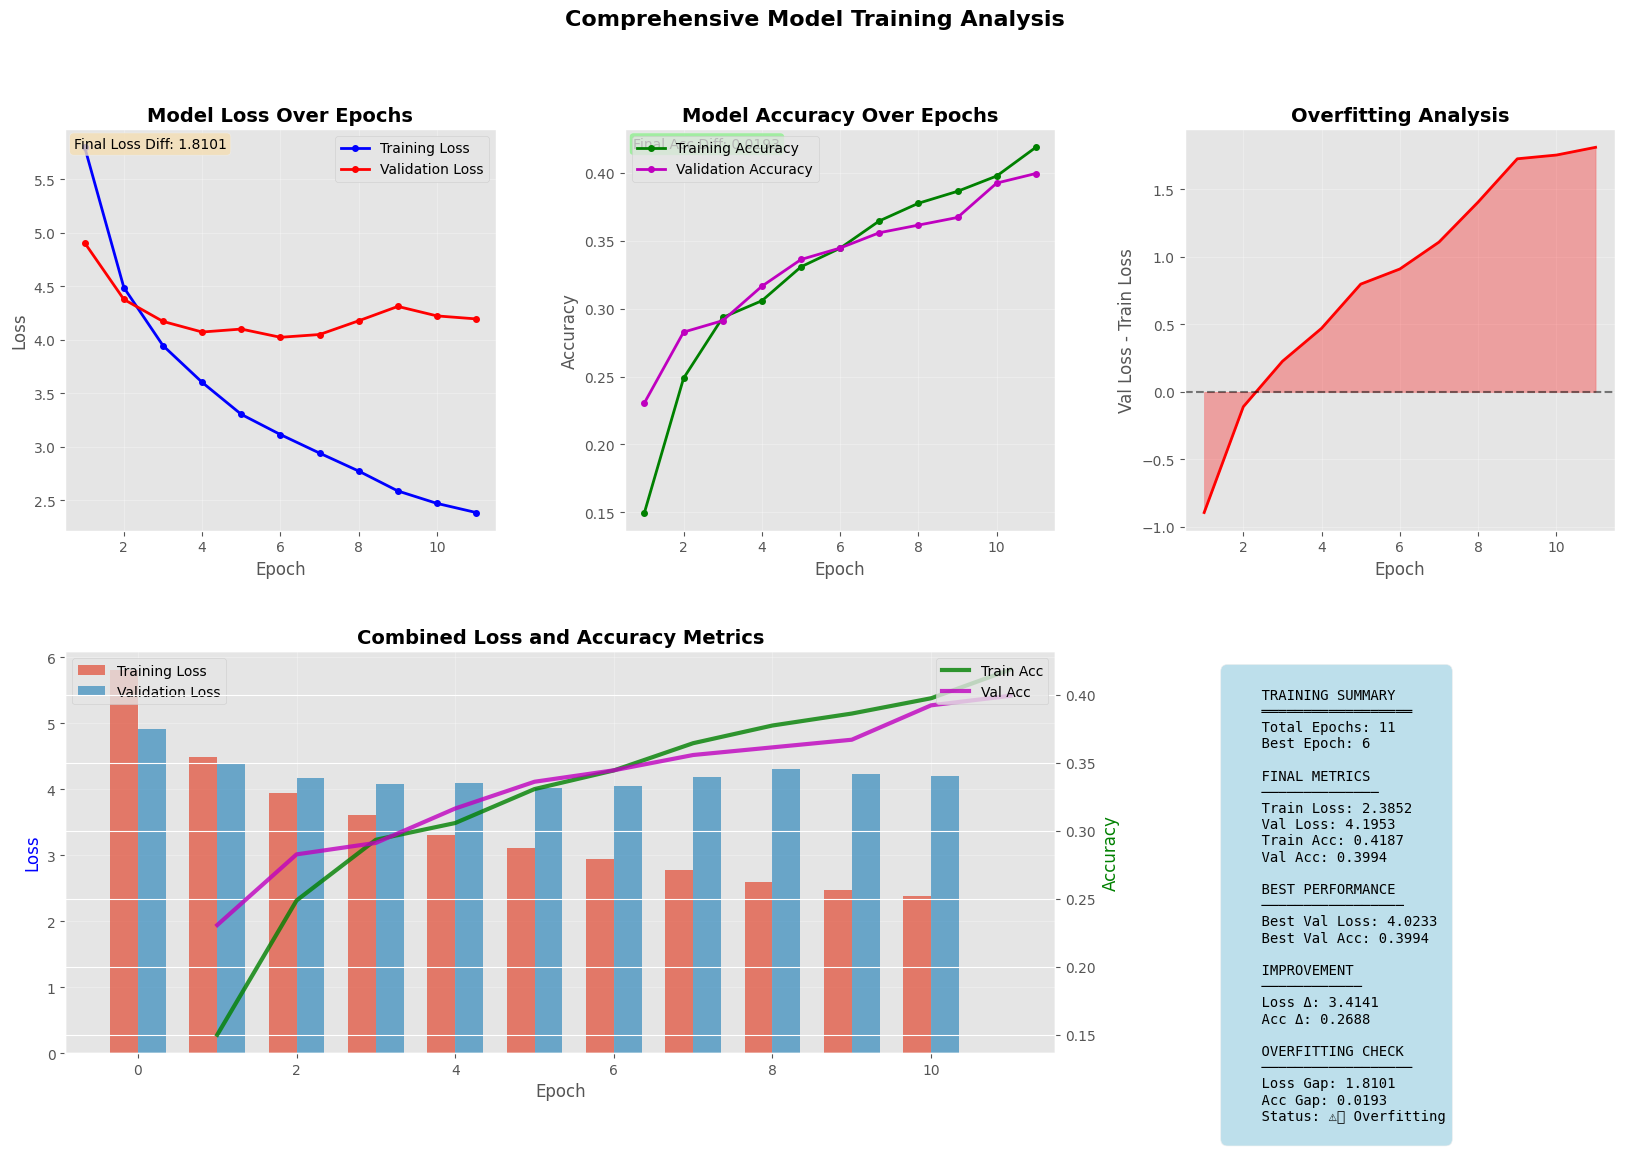


CALCULATING DETAILED PERFORMANCE METRICS
Using 500 samples for detailed metrics calculation
Generating predictions...
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step

📊 OVERALL METRICS
----------------------------------------
Accuracy:  0.3320
Precision: 0.2355
Recall:    0.3320
F1 Score:  0.2662


/tmp/ipykernel_36/1419402944.py:553: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

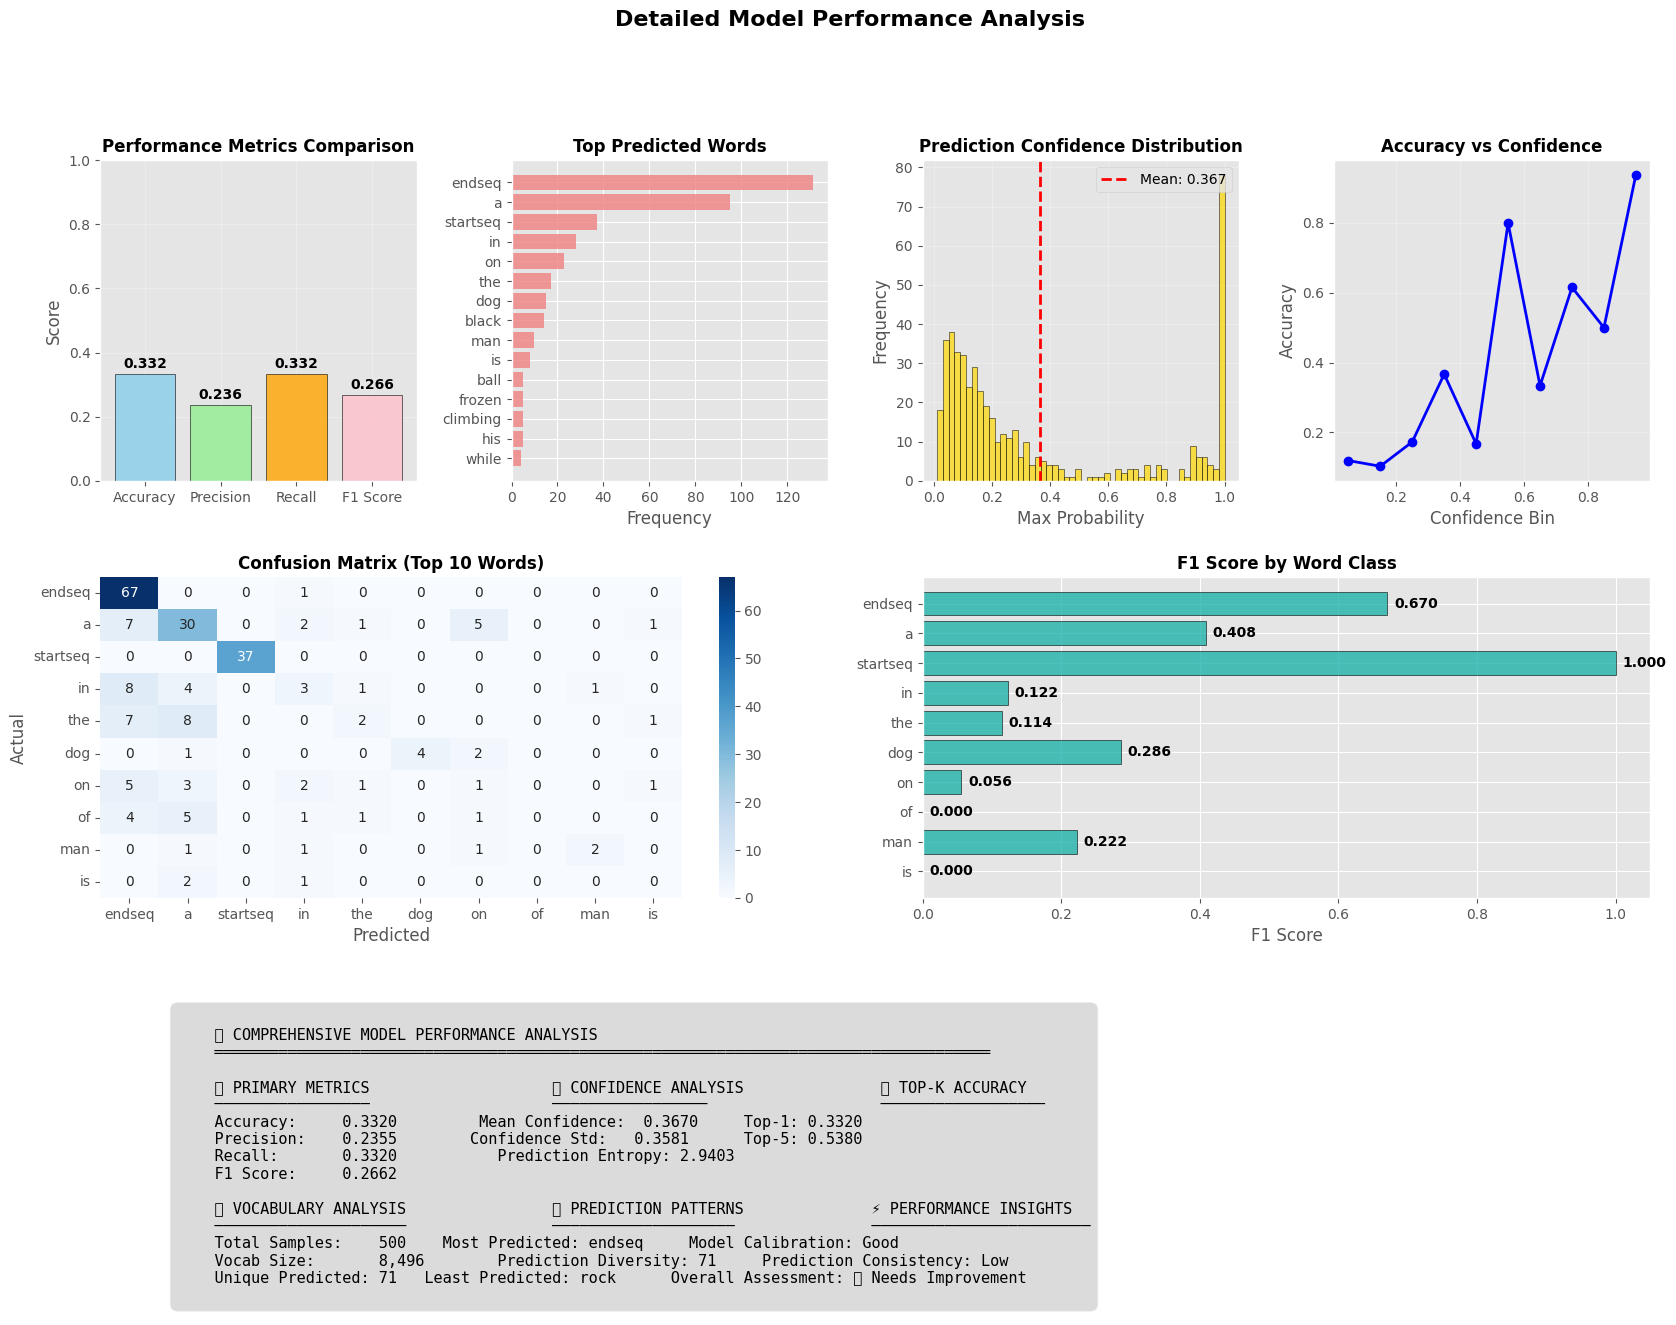


🎯 FINAL TRAINING RESULTS:
  - Training Loss: 2.3852
  - Validation Loss: 4.1953
  - Training Accuracy: 0.4187
  - Validation Accuracy: 0.3994

📊 DETAILED VALIDATION METRICS:
  - Precision: 0.2355
  - Recall: 0.3320
  - F1 Score: 0.2662
  - Mean Confidence: 0.3670

🔍 PERFORMANCE ANALYSIS:
----------------------------------------
⚠️  Model shows signs of overfitting (validation loss > training loss)
🔴 Poor F1 Score - Model needs significant improvement
⚠️  Training shows instability (high loss variance)
✅ Well-calibrated model (confidence matches accuracy)

SAMPLE PREDICTIONS

Sample 1:
Predicted: a black dog mouth a mouth

Sample 2:
Predicted: a black dog mouth a mouth

Sample 3:
Predicted: a girl girl in in in in in a in with a in with a in with a in with a in with a in with a in with a in with a in with a in with a in with

Sample 4:
Predicted: two dogs playing a a a a beach

Sample 5:
Predicted: a dog dog on the beach

MODEL TRAINING COMPLETED SUCCESSFULLY!
Files saved:
  - best_gru

In [ ]:

print("Preparing tokenizer and vocabulary...")

all_captions = []
for captions_list in image_to_captions.values():
    for caption in captions_list:
        
        caption = 'startseq ' + caption + ' endseq'
        all_captions.append(caption)


tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)


vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(caption.split()) for caption in all_captions)

print(f"Vocabulary size: {vocab_size}")
print(f"Maximum caption length: {max_length}")
print(f"Total captions: {len(all_captions)}")


def create_sequences(tokenizer, max_length, captions_list, feature):
    X1, X2, y = [], [], []
    
    
    for caption in captions_list:
       
        caption = 'startseq ' + caption + ' endseq'
        seq = tokenizer.texts_to_sequences([caption])[0]
        
        
        for i in range(1, len(seq)):
            in_seq, out_seq = seq[:i], seq[i]
            in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
            out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
            
            X1.append(feature)
            X2.append(in_seq)
            y.append(out_seq)
    
    return np.array(X1), np.array(X2), np.array(y)


print("\nPreparing training data...")
X1, X2, y = [], [], []
for image_name, captions in image_to_captions.items():
    if image_name in features_cache:
        feature = features_cache[image_name][0]  
        img_X1, img_X2, img_y = create_sequences(tokenizer, max_length, captions, feature)
        
        X1.extend(img_X1)
        X2.extend(img_X2)
        y.extend(img_y)

X1, X2, y = np.array(X1), np.array(X2), np.array(y)
print(f"Training data shape: X1={X1.shape}, X2={X2.shape}, y={y.shape}")


print("\nSplitting data...")
X1_train, X1_val, X2_train, X2_val, y_train, y_val = train_test_split(
    X1, X2, y, test_size=0.2, random_state=42
)

print(f"Training set: X1={X1_train.shape}, X2={X2_train.shape}, y={y_train.shape}")
print(f"Validation set: X1={X1_val.shape}, X2={X2_val.shape}, y={y_val.shape}")


def create_gru_model(vocab_size, max_length, feature_dim=4096):
    """
    Create a GRU-based image captioning model
    """
    print(f"\nCreating GRU model with:")
    print(f"  - Vocabulary size: {vocab_size}")
    print(f"  - Max sequence length: {max_length}")
    print(f"  - Feature dimension: {feature_dim}")
    
    
    input1 = Input(shape=(feature_dim,), name='image_features')
    fe1 = Dropout(0.5)(input1)
    fe2 = Dense(256, activation='relu', name='image_dense')(fe1)
    
    
    input2 = Input(shape=(max_length,), name='sequence_input')
    se1 = Embedding(vocab_size, 256, mask_zero=True, name='embedding')(input2)
    se2 = Dropout(0.5)(se1)
    se3 = GRU(256, return_sequences=False, name='gru')(se2)
    
    
    decoder1 = Add(name='add_features')([fe2, se3])
    decoder2 = Dense(256, activation='relu', name='decoder_dense1')(decoder1)
    decoder3 = Dropout(0.5)(decoder2)
    
    
    outputs = Dense(vocab_size, activation='softmax', name='output')(decoder3)
    
    
    model = Model(inputs=[input1, input2], outputs=outputs)
    
    return model


print("\n" + "="*50)
print("CREATING GRU IMAGE CAPTIONING MODEL")
print("="*50)

model = create_gru_model(vocab_size, max_length, feature_dim=X1.shape[1])


print("\nCompiling model...")
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


print("\nModel Architecture:")
model.summary()


try:
    plot_model(model, to_file='gru_captioning_model.png', show_shapes=True, show_layer_names=True)
    print("\nModel architecture saved as 'gru_captioning_model.png'")
except:
    print("\nNote: Could not save model plot (graphviz may not be installed)")


callbacks = [
    ModelCheckpoint(
        'best_gru_captioning_model.h5',
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        verbose=1,
        restore_best_weights=True
    )
]


print("\n" + "="*50)
print("STARTING MODEL TRAINING")
print("="*50)

start_time = time.time()


batch_size = 32
epochs = 20

print(f"Training parameters:")
print(f"  - Batch size: {batch_size}")
print(f"  - Epochs: {epochs}")
print(f"  - Training samples: {len(X1_train)}")
print(f"  - Validation samples: {len(X1_val)}")

try:
    history = model.fit(
        [X1_train, X2_train], y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=([X1_val, X2_val], y_val),
        callbacks=callbacks,
        verbose=1
    )
    
    training_time = time.time() - start_time
    print(f"\nTraining completed in {training_time/60:.2f} minutes!")
    
except Exception as e:
    print(f"Training error: {e}")
    print("Trying with smaller batch size...")
    
    
    batch_size = 16
    history = model.fit(
        [X1_train, X2_train], y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=([X1_val, X2_val], y_val),
        callbacks=callbacks,
        verbose=1
    )
    
    training_time = time.time() - start_time
    print(f"\nTraining completed in {training_time/60:.2f} minutes!")


model.save('final_gru_captioning_model.h5')
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("\nModel and tokenizer saved successfully!")


from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns


def plot_training_history(history):
    """Plot comprehensive training and validation metrics"""
    fig = plt.figure(figsize=(20, 12))
    
    
    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)
    
    
    ax1 = fig.add_subplot(gs[0, 0])
    epochs = range(1, len(history.history['loss']) + 1)
    ax1.plot(epochs, history.history['loss'], 'bo-', label='Training Loss', linewidth=2, markersize=4)
    ax1.plot(epochs, history.history['val_loss'], 'ro-', label='Validation Loss', linewidth=2, markersize=4)
    ax1.set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    loss_diff = abs(final_val_loss - final_train_loss)
    ax1.text(0.02, 0.98, f'Final Loss Diff: {loss_diff:.4f}', 
             transform=ax1.transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(epochs, history.history['accuracy'], 'go-', label='Training Accuracy', linewidth=2, markersize=4)
    ax2.plot(epochs, history.history['val_accuracy'], 'mo-', label='Validation Accuracy', linewidth=2, markersize=4)
    ax2.set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    acc_diff = abs(final_train_acc - final_val_acc)
    ax2.text(0.02, 0.98, f'Final Acc Diff: {acc_diff:.4f}', 
             transform=ax2.transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
    
    
    ax3 = fig.add_subplot(gs[0, 2])
    if 'lr' in history.history:
        ax3.plot(epochs, history.history['lr'], 'co-', linewidth=2, markersize=4)
        ax3.set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
        ax3.set_xlabel('Epoch')
        ax3.set_ylabel('Learning Rate')
        ax3.set_yscale('log')
    else:
        
        train_loss = np.array(history.history['loss'])
        val_loss = np.array(history.history['val_loss'])
        overfitting_score = val_loss - train_loss
        ax3.plot(epochs, overfitting_score, 'r-', linewidth=2)
        ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        ax3.set_title('Overfitting Analysis', fontsize=14, fontweight='bold')
        ax3.set_xlabel('Epoch')
        ax3.set_ylabel('Val Loss - Train Loss')
        ax3.fill_between(epochs, overfitting_score, 0, alpha=0.3, 
                        color='red' if np.mean(overfitting_score[-3:]) > 0 else 'green')
    ax3.grid(True, alpha=0.3)
    
    
    ax4 = fig.add_subplot(gs[1, :2])
    x_pos = np.arange(len(epochs))
    width = 0.35
    
    ax4.bar(x_pos - width/2, history.history['loss'], width, label='Training Loss', alpha=0.7)
    ax4.bar(x_pos + width/2, history.history['val_loss'], width, label='Validation Loss', alpha=0.7)
    
    
    ax4_twin = ax4.twinx()
    ax4_twin.plot(epochs, history.history['accuracy'], 'g-', label='Train Acc', linewidth=3, alpha=0.8)
    ax4_twin.plot(epochs, history.history['val_accuracy'], 'm-', label='Val Acc', linewidth=3, alpha=0.8)
    
    ax4.set_title('Combined Loss and Accuracy Metrics', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Loss', color='blue')
    ax4_twin.set_ylabel('Accuracy', color='green')
    ax4.legend(loc='upper left')
    ax4_twin.legend(loc='upper right')
    ax4.grid(True, alpha=0.3)
    
    
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.axis('off')
    
    
    best_epoch = np.argmin(history.history['val_loss']) + 1
    best_val_loss = min(history.history['val_loss'])
    best_val_acc = max(history.history['val_accuracy'])
    total_epochs = len(history.history['loss'])
    
    
    loss_improvement = history.history['loss'][0] - history.history['loss'][-1]
    acc_improvement = history.history['accuracy'][-1] - history.history['accuracy'][0]
    
    stats_text = f"""
    TRAINING SUMMARY
    ══════════════════
    Total Epochs: {total_epochs}
    Best Epoch: {best_epoch}
    
    FINAL METRICS
    ──────────────
    Train Loss: {final_train_loss:.4f}
    Val Loss: {final_val_loss:.4f}
    Train Acc: {final_train_acc:.4f}
    Val Acc: {final_val_acc:.4f}
    
    BEST PERFORMANCE
    ─────────────────
    Best Val Loss: {best_val_loss:.4f}
    Best Val Acc: {best_val_acc:.4f}
    
    IMPROVEMENT
    ────────────
    Loss Δ: {loss_improvement:.4f}
    Acc Δ: {acc_improvement:.4f}
    
    OVERFITTING CHECK
    ──────────────────
    Loss Gap: {loss_diff:.4f}
    Acc Gap: {acc_diff:.4f}
    Status: {'⚠️ Overfitting' if loss_diff > 0.1 else '✅ Good Fit'}
    """
    
    ax5.text(0.1, 0.95, stats_text, transform=ax5.transAxes, fontsize=10,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8))
    
    plt.suptitle('Comprehensive Model Training Analysis', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()


def calculate_detailed_metrics(model, X1_test, X2_test, y_test, tokenizer, sample_size=1000):
    """Calculate comprehensive metrics including F1 score, precision, recall"""
    print("\n" + "="*60)
    print("CALCULATING DETAILED PERFORMANCE METRICS")
    print("="*60)
    
    
    if len(X1_test) > sample_size:
        indices = np.random.choice(len(X1_test), sample_size, replace=False)
        X1_sample = X1_test[indices]
        X2_sample = X2_test[indices]
        y_sample = y_test[indices]
        print(f"Using {sample_size} samples for detailed metrics calculation")
    else:
        X1_sample = X1_test
        X2_sample = X2_test
        y_sample = y_test
        print(f"Using all {len(X1_test)} samples for detailed metrics calculation")
    
    
    print("Generating predictions...")
    predictions = model.predict([X1_sample, X2_sample], batch_size=32, verbose=1)
    
    
    y_pred_classes = np.argmax(predictions, axis=1)
    y_true_classes = np.argmax(y_sample, axis=1)
    
    
    accuracy = accuracy_score(y_true_classes, y_pred_classes)
    precision = precision_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)
    recall = recall_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)
    f1 = f1_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)
    
    
    vocab_size = len(tokenizer.word_index) + 1
    word_frequencies = Counter(y_true_classes)
    top_words = word_frequencies.most_common(20)
    
    print(f"\n📊 OVERALL METRICS")
    print("-" * 40)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    
    
    fig = plt.figure(figsize=(20, 15))
    gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)
    
    
    ax1 = fig.add_subplot(gs[0, 0])
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    values = [accuracy, precision, recall, f1]
    colors = ['skyblue', 'lightgreen', 'orange', 'pink']
    
    bars = ax1.bar(metrics, values, color=colors, alpha=0.8, edgecolor='black')
    ax1.set_title('Performance Metrics Comparison', fontweight='bold', fontsize=12)
    ax1.set_ylabel('Score')
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.3)
    
    
    for bar, value in zip(bars, values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
    
    
    ax2 = fig.add_subplot(gs[0, 1])
    pred_word_freq = Counter(y_pred_classes)
    top_pred_words = pred_word_freq.most_common(15)
    
    words = []
    freqs = []
    for word_idx, freq in top_pred_words:
        if word_idx in tokenizer.index_word:
            words.append(tokenizer.index_word[word_idx])
            freqs.append(freq)
        elif word_idx == 0:
            words.append('<PAD>')
            freqs.append(freq)
    
    ax2.barh(words[::-1], freqs[::-1], color='lightcoral', alpha=0.8)
    ax2.set_title('Top Predicted Words', fontweight='bold', fontsize=12)
    ax2.set_xlabel('Frequency')
    
    
    ax3 = fig.add_subplot(gs[0, 2])
    max_probs = np.max(predictions, axis=1)
    ax3.hist(max_probs, bins=50, color='gold', alpha=0.7, edgecolor='black')
    ax3.axvline(np.mean(max_probs), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {np.mean(max_probs):.3f}')
    ax3.set_title('Prediction Confidence Distribution', fontweight='bold', fontsize=12)
    ax3.set_xlabel('Max Probability')
    ax3.set_ylabel('Frequency')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    
    ax4 = fig.add_subplot(gs[0, 3])
    confidence_bins = np.linspace(0, 1, 11)
    bin_accuracies = []
    bin_centers = []
    
    for i in range(len(confidence_bins)-1):
        mask = (max_probs >= confidence_bins[i]) & (max_probs < confidence_bins[i+1])
        if np.sum(mask) > 0:
            bin_acc = accuracy_score(y_true_classes[mask], y_pred_classes[mask])
            bin_accuracies.append(bin_acc)
            bin_centers.append((confidence_bins[i] + confidence_bins[i+1]) / 2)
    
    ax4.plot(bin_centers, bin_accuracies, 'bo-', linewidth=2, markersize=6)
    ax4.set_title('Accuracy vs Confidence', fontweight='bold', fontsize=12)
    ax4.set_xlabel('Confidence Bin')
    ax4.set_ylabel('Accuracy')
    ax4.grid(True, alpha=0.3)
    
    
    ax5 = fig.add_subplot(gs[1, :2])
    top_10_indices = [idx for idx, _ in top_words[:10]]
    
    
    mask = np.isin(y_true_classes, top_10_indices)
    if np.sum(mask) > 0:
        y_true_filtered = y_true_classes[mask]
        y_pred_filtered = y_pred_classes[mask]
        
        cm = confusion_matrix(y_true_filtered, y_pred_filtered, labels=top_10_indices)
        
        
        word_labels = []
        for idx in top_10_indices:
            if idx in tokenizer.index_word:
                word_labels.append(tokenizer.index_word[idx][:8]) 
            elif idx == 0:
                word_labels.append('<PAD>')
            else:
                word_labels.append(f'UNK_{idx}')
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=word_labels, yticklabels=word_labels, ax=ax5)
        ax5.set_title('Confusion Matrix (Top 10 Words)', fontweight='bold', fontsize=12)
        ax5.set_xlabel('Predicted')
        ax5.set_ylabel('Actual')
    
    
    ax6 = fig.add_subplot(gs[1, 2:])
    if len(top_10_indices) > 1:
        per_class_f1 = f1_score(y_true_classes, y_pred_classes, 
                               labels=top_10_indices, average=None, zero_division=0)
        
        word_labels_f1 = []
        valid_f1_scores = []
        for i, idx in enumerate(top_10_indices):
            if i < len(per_class_f1):
                if idx in tokenizer.index_word:
                    word_labels_f1.append(tokenizer.index_word[idx][:10])
                elif idx == 0:
                    word_labels_f1.append('<PAD>')
                else:
                    word_labels_f1.append(f'UNK_{idx}')
                valid_f1_scores.append(per_class_f1[i])
        
        bars = ax6.barh(word_labels_f1[::-1], valid_f1_scores[::-1], 
                       color='lightseagreen', alpha=0.8, edgecolor='black')
        ax6.set_title('F1 Score by Word Class', fontweight='bold', fontsize=12)
        ax6.set_xlabel('F1 Score')
        
        
        for bar, score in zip(bars, valid_f1_scores[::-1]):
            ax6.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{score:.3f}', ha='left', va='center', fontweight='bold')
    
    
    ax7 = fig.add_subplot(gs[2, :])
    ax7.axis('off')
    
    
    entropy = -np.mean(np.sum(predictions * np.log(predictions + 1e-10), axis=1))
    top1_acc = accuracy
    top5_acc = np.mean([1 if true_idx in np.argsort(pred)[-5:] 
                       else 0 for pred, true_idx in zip(predictions, y_true_classes)])
    
    summary_text = f"""
    📊 COMPREHENSIVE MODEL PERFORMANCE ANALYSIS
    ═════════════════════════════════════════════════════════════════════════════════════
    
    🎯 PRIMARY METRICS                    📈 CONFIDENCE ANALYSIS               🏆 TOP-K ACCURACY
    ─────────────────                    ─────────────────                   ──────────────────
    Accuracy:     {accuracy:.4f}         Mean Confidence:  {np.mean(max_probs):.4f}     Top-1: {top1_acc:.4f}
    Precision:    {precision:.4f}        Confidence Std:   {np.std(max_probs):.4f}      Top-5: {top5_acc:.4f}
    Recall:       {recall:.4f}           Prediction Entropy: {entropy:.4f}            
    F1 Score:     {f1:.4f}               
    
    📚 VOCABULARY ANALYSIS                🔍 PREDICTION PATTERNS              ⚡ PERFORMANCE INSIGHTS
    ─────────────────────                ────────────────────               ────────────────────────
    Total Samples:    {len(X1_sample):,}    Most Predicted: {tokenizer.index_word.get(pred_word_freq.most_common(1)[0][0], 'UNK')}     Model Calibration: {'Good' if abs(np.mean(max_probs) - accuracy) < 0.1 else 'Poor'}
    Vocab Size:       {vocab_size:,}        Prediction Diversity: {len(set(y_pred_classes))}     Prediction Consistency: {'High' if np.std(max_probs) < 0.2 else 'Low'}
    Unique Predicted: {len(set(y_pred_classes))}   Least Predicted: {tokenizer.index_word.get(pred_word_freq.most_common()[-1][0], 'UNK')}      Overall Assessment: {'🟢 Excellent' if f1 > 0.8 else '🟡 Good' if f1 > 0.6 else '🔴 Needs Improvement'}
    """
    
    ax7.text(0.05, 0.95, summary_text, transform=ax7.transAxes, fontsize=11,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8))
    
    plt.suptitle('Detailed Model Performance Analysis', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'predictions': y_pred_classes,
        'true_labels': y_true_classes,
        'confidence_scores': max_probs
    }


print("\n" + "="*50)
print("TRAINING RESULTS & COMPREHENSIVE ANALYSIS")
print("="*50)

plot_training_history(history)


detailed_metrics = calculate_detailed_metrics(
    model, X1_val, X2_val, y_val, tokenizer, sample_size=500
)


final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"\n🎯 FINAL TRAINING RESULTS:")
print(f"  - Training Loss: {final_train_loss:.4f}")
print(f"  - Validation Loss: {final_val_loss:.4f}")
print(f"  - Training Accuracy: {final_train_acc:.4f}")
print(f"  - Validation Accuracy: {final_val_acc:.4f}")

print(f"\n📊 DETAILED VALIDATION METRICS:")
print(f"  - Precision: {detailed_metrics['precision']:.4f}")
print(f"  - Recall: {detailed_metrics['recall']:.4f}")
print(f"  - F1 Score: {detailed_metrics['f1_score']:.4f}")
print(f"  - Mean Confidence: {np.mean(detailed_metrics['confidence_scores']):.4f}")


def analyze_model_performance(history, detailed_metrics):
    """Provide comprehensive performance analysis"""
    print(f"\n🔍 PERFORMANCE ANALYSIS:")
    print("-" * 40)
    
    
    final_loss_diff = final_val_loss - final_train_loss
    final_acc_diff = final_train_acc - final_val_acc
    
    if final_loss_diff > 0.1:
        print("⚠️  Model shows signs of overfitting (validation loss > training loss)")
    elif final_loss_diff < -0.1:
        print("⚠️  Model might be underfitting (training loss > validation loss)")
    else:
        print("✅ Model shows good generalization")
    
    
    f1 = detailed_metrics['f1_score']
    if f1 > 0.8:
        print("🟢 Excellent F1 Score - Model performs very well")
    elif f1 > 0.6:
        print("🟡 Good F1 Score - Model performs reasonably well")
    elif f1 > 0.4:
        print("🟠 Moderate F1 Score - Model needs improvement")
    else:
        print("🔴 Poor F1 Score - Model needs significant improvement")
    
    
    loss_variance = np.var(history.history['val_loss'][-5:])
    if loss_variance < 0.001:
        print("✅ Training appears stable (low loss variance)")
    else:
        print("⚠️  Training shows instability (high loss variance)")
    
    
    confidence_mean = np.mean(detailed_metrics['confidence_scores'])
    accuracy = detailed_metrics['accuracy']
    calibration_gap = abs(confidence_mean - accuracy)
    
    if calibration_gap < 0.05:
        print("✅ Well-calibrated model (confidence matches accuracy)")
    else:
        print(f"⚠️  Model calibration gap: {calibration_gap:.3f}")

analyze_model_performance(history, detailed_metrics)


def generate_caption(model, tokenizer, feature, max_length):
    """Generate caption for a given image feature"""
    in_text = 'startseq'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        pred = model.predict([feature, sequence], verbose=0)
        pred = np.argmax(pred)
        word = tokenizer.index_word.get(pred)
        if word is None:
            break
        in_text += ' ' + word
        if word == 'endseq':
            break
    return in_text.replace('startseq ', '').replace(' endseq', '')


print("\n" + "="*50)
print("SAMPLE PREDICTIONS")
print("="*50)


sample_indices = np.random.choice(len(X1_val), min(5, len(X1_val)), replace=False)

for i, idx in enumerate(sample_indices):
    feature = X1_val[idx:idx+1]  
    predicted_caption = generate_caption(model, tokenizer, feature, max_length)
    print(f"\nSample {i+1}:")
    print(f"Predicted: {predicted_caption}")

print("\n" + "="*50)
print("MODEL TRAINING COMPLETED SUCCESSFULLY!")
print("="*50)
print(f"Files saved:")
print(f"  - best_gru_captioning_model.h5 (best model)")
print(f"  - final_gru_captioning_model.h5 (final model)")
print(f"  - tokenizer.pkl (tokenizer)")
print(f"  - image_features.pkl (image features)")